# PhysCLIP Benchmark Suite (Clean)

This notebook provides a **single, consistent benchmark pipeline** for **three baselines**:

- **CLIP (OpenAI / open\_clip)**  
- **AstroCLIP** (image–spectrum aligned; **no natural-language text encoder**)  
- **PhysCLIP** (your CLIP-style astro model)

## Tasks

| Task | Dataset | Metric(s) | Notes |
|---|---|---|---|
| Image classification | SpaceNet | Accuracy | 8-way astro images |
| Image classification | GZD-5 | Balanced Acc, Macro-F1 | imbalanced morphology |
| Image classification | CIFAR-10 | Top-1 Accuracy | sanity-check / quick run |
| Cross-modal retrieval | PhysCLIP-Arxiv | Recall@1/5/10 | image↔caption retrieval |

**Design goals**
- Minimal reruns: **cache embeddings + results to Google Drive**.
- Clear structure: each section is self-contained.
- Zero-shot is computed **only for CLIP-like models** (CLIP / PhysCLIP). AstroCLIP is not language-aligned.


In [ ]:
# (0) Mount Drive + define project folders (Drive-persistent)
from pathlib import Path
import os

# Ensure AstroCLIP checkpoints can be loaded on newer PyTorch (avoid weights_only restrictions)
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
# If you already imported torch in this runtime, restart the kernel/runtime before continuing.


IN_COLAB = "google.colab" in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

# Change this to your folder
PROJECT_ROOT = Path("/content/drive/MyDrive/physclip_benchmark") if IN_COLAB else Path.cwd()

DATA_ROOT    = PROJECT_ROOT / "data"
CKPT_ROOT    = PROJECT_ROOT / "checkpoints"
CACHE_ROOT   = PROJECT_ROOT / "cache"          # optional: HF snapshots, dataset caches
RESULTS_ROOT = PROJECT_ROOT / "results"
FIG_ROOT     = RESULTS_ROOT / "figures"
EMB_ROOT     = RESULTS_ROOT / "embeddings"

for p in [DATA_ROOT, CKPT_ROOT, CACHE_ROOT, RESULTS_ROOT, FIG_ROOT, EMB_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CKPT_ROOT:", CKPT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)


In [ ]:
# (1) Install deps (Colab / fresh env)
# Run once per fresh runtime, THEN restart the runtime/kernel.
!pip -q install -U pip

# Core benchmark deps
!pip -q install -U open-clip-torch scikit-learn pandas matplotlib tqdm pillow safetensors

# AstroCLIP runtime deps (since we install AstroCLIP with --no-deps to avoid pinned torch/torchvision)
!pip -q install -U lightning torchmetrics omegaconf fvcore iopath astropy "huggingface_hub>=0.34.0,<1.0" jaxtyping

# DINOv2 + AstroCLIP WITHOUT pulling their pinned torch/torchvision requirements
!pip -q install --no-deps -U git+https://github.com/facebookresearch/dinov2.git@2302b6bf46953431b969155307b9bed152754069
!pip -q install --no-deps -U git+https://github.com/PolymathicAI/AstroCLIP.git


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.0.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# (2) Imports + utilities
import json
import re
import math
import random
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [ ]:
# (3) Dataset utilities (Drive-persistent: metadata.csv + images/ OR URL-based images)
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Union
import json, hashlib, time

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

# Optional: only used if your metadata contains URLs (e.g., Legacy Survey cutouts)
try:
    import requests
except Exception:
    requests = None


def _is_url(s: str) -> bool:
    s = str(s)
    return s.startswith("http://") or s.startswith("https://")


def _sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()


def _download_to(path: Path, url: str, timeout: int = 30, retries: int = 2) -> None:
    """
    Download URL -> path. Writes atomically (tmp then rename).
    Requires `requests`.
    """
    if requests is None:
        raise RuntimeError(
            "requests is not available, but your metadata contains URLs. "
            "Install requests or provide local image files."
        )

    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")

    last_err = None
    for _ in range(retries + 1):
        try:
            with requests.get(url, stream=True, timeout=timeout) as r:
                r.raise_for_status()
                with open(tmp, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 256):
                        if chunk:
                            f.write(chunk)
            tmp.replace(path)
            return
        except Exception as e:
            last_err = e
            try:
                if tmp.exists():
                    tmp.unlink()
            except Exception:
                pass
            time.sleep(0.5)

    raise last_err


def ensure_label_map(dataset_root: Path, labels: List[str]) -> Dict[str, int]:
    """
    Create (or load) a stable label2id mapping stored at dataset_root/label_map.json.
    Sorting labels ensures deterministic ids across runs.
    """
    dataset_root = Path(dataset_root)
    lm_path = dataset_root / "label_map.json"
    if lm_path.exists():
        with open(lm_path, "r", encoding="utf-8") as f:
            label2id = json.load(f)
        return {str(k): int(v) for k, v in label2id.items()}

    uniq = sorted({str(x) for x in labels})
    label2id = {lab: i for i, lab in enumerate(uniq)}
    with open(lm_path, "w", encoding="utf-8") as f:
        json.dump(label2id, f, indent=2, ensure_ascii=False)
    return label2id


def load_label_map(dataset_root: Path) -> Dict[str, int]:
    lm_path = Path(dataset_root) / "label_map.json"
    if not lm_path.exists():
        raise FileNotFoundError(
            f"label_map.json not found at {lm_path}. "
            "Run the embeddings cell once to create it."
        )
    with open(lm_path, "r", encoding="utf-8") as f:
        label2id = json.load(f)
    return {str(k): int(v) for k, v in label2id.items()}


class ImageCSVDataset(Dataset):
    """
    Expects: dataset_root/metadata.csv with columns:
      - img_path (relative path under dataset_root OR full URL)
      - label
      - split  (train/test)
    Notes:
      - If your CSV uses 'urls' or 'url' instead of 'img_path', it will be auto-renamed.
      - For URL rows, images are cached under dataset_root/url_cache/.
    """
    def __init__(
        self,
        dataset_root: Union[str, Path],
        split: str,
        transform=None,
        allow_urls: bool = True,
        url_cache_dirname: str = "url_cache",
    ):
        self.dataset_root = Path(dataset_root)
        self.split = str(split).lower().strip()
        self.transform = transform
        self.allow_urls = allow_urls
        self.url_cache = self.dataset_root / url_cache_dirname

        meta_path = self.dataset_root / "metadata.csv"
        if not meta_path.exists():
            raise FileNotFoundError(f"Missing metadata.csv at {meta_path}")

        df = pd.read_csv(meta_path)

        # Normalize column names
        if "img_path" not in df.columns:
            for alt in ["urls", "url", "image", "path", "filepath", "file_path"]:
                if alt in df.columns:
                    df = df.rename(columns={alt: "img_path"})
                    break
        if "img_path" not in df.columns:
            raise ValueError(
                f"metadata.csv must contain an img_path (or urls/url/path) column. Columns={list(df.columns)}"
            )

        for col in ["label", "split"]:
            if col not in df.columns:
                raise ValueError(f"metadata.csv must contain '{col}'. Columns={list(df.columns)}")

        df["split"] = df["split"].astype(str).str.lower().str.strip()
        df = df[df["split"] == self.split].reset_index(drop=True)
        if len(df) == 0:
            raise ValueError(f"No rows for split='{self.split}' in {meta_path}")

        label2id = ensure_label_map(self.dataset_root, df["label"].astype(str).tolist())
        self.label2id = label2id
        self.id2label = {v: k for k, v in label2id.items()}

        self.img_paths = df["img_path"].astype(str).tolist()
        self.y = np.array([label2id[str(lab)] for lab in df["label"].astype(str).tolist()], dtype=np.int64)

    def __len__(self) -> int:
        return len(self.img_paths)

    def classnames(self) -> List[str]:
        return [self.id2label[i] for i in range(len(self.id2label))]

    def _resolve_local(self, p: str) -> Path:
        pp = Path(p)
        return pp if pp.is_absolute() else (self.dataset_root / pp)

    def _url_cache_path(self, url: str) -> Path:
        return self.url_cache / f"{_sha1(url)}.jpg"

    def __getitem__(self, idx: int):
        p = self.img_paths[idx]

        if _is_url(p):
            if not self.allow_urls:
                raise RuntimeError("Encountered URL img_path but allow_urls=False.")
            cache_fp = self._url_cache_path(p)
            if not cache_fp.exists():
                _download_to(cache_fp, p)
            img = Image.open(cache_fp).convert("RGB")
        else:
            fp = self._resolve_local(p)
            img = Image.open(fp).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, int(self.y[idx])


def assert_dataset_ready(dataset_root: Path, allow_urls: bool = False, n_check: int = 20) -> None:
    """
    Lightweight sanity check: metadata exists; required cols exist;
    and (if local paths) a few files exist.
    """
    dataset_root = Path(dataset_root)
    meta_path = dataset_root / "metadata.csv"
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing {meta_path}")

    df = pd.read_csv(meta_path)
    if "img_path" not in df.columns:
        for alt in ["urls", "url", "image", "path", "filepath", "file_path"]:
            if alt in df.columns:
                df = df.rename(columns={alt: "img_path"})
                break

    for col in ["img_path", "label", "split"]:
        if col not in df.columns:
            raise ValueError(f"metadata.csv missing required column '{col}'. Columns={list(df.columns)}")

    # Check some local files exist (skip URLs if allow_urls=True)
    sample = df.sample(min(n_check, len(df)), random_state=0)
    missing = 0
    checked = 0
    for p in sample["img_path"].astype(str).tolist():
        if _is_url(p):
            if not allow_urls:
                raise ValueError("metadata.csv contains URLs but allow_urls=False.")
            continue
        checked += 1
        fp = (dataset_root / p) if not Path(p).is_absolute() else Path(p)
        if not fp.exists():
            missing += 1

    if checked > 0 and missing == checked:
        raise FileNotFoundError(
            f"All checked local files were missing under {dataset_root}. "
            f"Either img_path is wrong OR files are not present."
        )

    print(f"[OK] Dataset ready: {dataset_root} | rows={len(df)} | allow_urls={allow_urls}")


## Baseline loading

In [ ]:
# (4) Baseline model interfaces (CLIP / PhysCLIP / AstroCLIP)
from dataclasses import dataclass
from typing import Callable, Optional, List
from pathlib import Path
import sys, subprocess
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

@dataclass
class Baseline:
    name: str
    has_text: bool
    preprocess: Callable
    encode_image_batch: Callable[[torch.Tensor], torch.Tensor]   # returns (B,D) normalized on CPU
    encode_text_batch: Optional[Callable[[List[str]], torch.Tensor]] = None  # returns (B,D) normalized on CPU


# ---- OpenCLIP (CLIP baseline + loader used by PhysCLIP) ----
def _import_open_clip():
    """
    Some Colab runtimes end up with a mixed Pillow install and open_clip fails with:
      ImportError: cannot import name '_Ink' from PIL._typing
    If that happens, we pin Pillow and retry.
    """
    try:
        import open_clip
        return open_clip
    except Exception as e:
        msg = str(e)
        if ("PIL._typing" in msg) or ("_Ink" in msg) or ("Ink" in msg and "PIL" in msg):
            print("[fix] open_clip import failed due to Pillow typing mismatch. Pinning Pillow and retrying...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pillow==10.4.0"])
            import importlib
            importlib.invalidate_caches()
            import open_clip
            return open_clip
        raise

open_clip = _import_open_clip()


def load_openclip_baseline(model_name: str = "ViT-B-32", pretrained: str = "openai", baseline_name: str = "CLIP(OpenAI)") -> Baseline:
    model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    model = model.to(device).eval()
    tokenizer = open_clip.get_tokenizer(model_name)

    @torch.no_grad()
    def enc_img(x: torch.Tensor) -> torch.Tensor:
        z = model.encode_image(x.to(device))
        z = z / z.norm(dim=-1, keepdim=True)
        return z.detach().cpu()

    @torch.no_grad()
    def enc_txt(texts: List[str]) -> torch.Tensor:
        toks = tokenizer(texts).to(device)
        z = model.encode_text(toks)
        z = z / z.norm(dim=-1, keepdim=True)
        return z.detach().cpu()

    return Baseline(
        name=baseline_name,
        has_text=True,
        preprocess=preprocess,
        encode_image_batch=enc_img,
        encode_text_batch=enc_txt,
    )

clip = load_openclip_baseline("ViT-B-32", "openai", baseline_name="CLIP(OpenAI)")
print("Loaded baseline:", clip.name)


[fix] open_clip import failed due to Pillow typing mismatch. Pinning Pillow and retrying...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded baseline: CLIP(OpenAI)


In [ ]:
# ---- PhysCLIP baseline (open_clip-compatible checkpoint) ----
# Goal: reuse the PhysCLIP weights you already saved to Google Drive (CKPT_ROOT).
# In the older notebook you used:
#   snapshot_download(repo_id="tnnanh1005/physclip_astrobert", local_dir=CKPT_ROOT/"physclip_astrobert")
# which creates a DIRECTORY. This cell supports both:
#   - a direct checkpoint FILE path
#   - a checkpoint DIRECTORY (we auto-find the largest *.safetensors/*.pt/*.bin inside it)

import os
from pathlib import Path
import torch

PHYSCLIP_MODEL_NAME = "ViT-B-32"  # change if your PhysCLIP arch differs
PHYSCLIP_CKPT_PATH  = CKPT_ROOT / "physclip_astrobert"  # directory OR file in Drive

def _resolve_ckpt_file(p: Path) -> Path | None:
    p = Path(p)
    if p.is_file():
        return p
    if p.is_dir():
        exts = ["*.safetensors", "*.pt", "*.pth", "*.bin", "*.ckpt"]
        cands = []
        for ext in exts:
            cands.extend(list(p.rglob(ext)))
        # ignore tiny files
        cands = [c for c in cands if c.is_file() and c.stat().st_size > 1024 * 1024]
        if not cands:
            return None
        cands = sorted(cands, key=lambda x: x.stat().st_size, reverse=True)
        return cands[0]
    return None

def _load_openclip_checkpoint(model, ckpt_path: Path):
    ckpt_path = Path(ckpt_path)
    if ckpt_path.suffix == ".safetensors":
        from safetensors.torch import load_file as st_load
        state = st_load(str(ckpt_path))
    else:
        obj = torch.load(str(ckpt_path), map_location="cpu")
        if isinstance(obj, dict) and "state_dict" in obj and isinstance(obj["state_dict"], dict):
            state = obj["state_dict"]
        elif isinstance(obj, dict) and "model" in obj and isinstance(obj["model"], dict):
            state = obj["model"]
        elif isinstance(obj, dict):
            # assume it's already a state dict
            state = obj
        else:
            raise ValueError(f"Unsupported checkpoint format: {type(obj)}")

    # clean common prefixes
    cleaned = {}
    for k, v in state.items():
        for pref in ("model.", "module."):
            if k.startswith(pref):
                k = k[len(pref):]
        cleaned[k] = v

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    return missing, unexpected

physclip = None

ckpt_file = _resolve_ckpt_file(PHYSCLIP_CKPT_PATH)
if ckpt_file is None:
    print("PhysCLIP checkpoint not found (no weight file detected) at:", PHYSCLIP_CKPT_PATH)
    if Path(PHYSCLIP_CKPT_PATH).is_dir():
        print("Directory contents (top-level):")
        print(sorted([p.name for p in Path(PHYSCLIP_CKPT_PATH).iterdir()])[:50])
    print("Fix: set PHYSCLIP_CKPT_PATH to the actual weight file (e.g., *.safetensors) OR keep it as a dir that contains one.")
else:
    print("PhysCLIP checkpoint file:", ckpt_file)

    # create the architecture shell (no pretrained weights), then load your PhysCLIP weights
    phys_model, _, phys_preprocess = open_clip.create_model_and_transforms(PHYSCLIP_MODEL_NAME, pretrained=None)
    phys_model = phys_model.to(device).eval()

    missing, unexpected = _load_openclip_checkpoint(phys_model, ckpt_file)
    print("PhysCLIP loaded.")
    print("  missing keys:", len(missing))
    print("  unexpected keys:", len(unexpected))

    phys_tokenizer = open_clip.get_tokenizer(PHYSCLIP_MODEL_NAME)

    @torch.no_grad()
    def phys_enc_img(x: torch.Tensor) -> torch.Tensor:
        z = phys_model.encode_image(x.to(device))
        z = z / z.norm(dim=-1, keepdim=True)
        return z.detach().cpu()

    @torch.no_grad()
    def phys_enc_txt(texts: List[str]) -> torch.Tensor:
        toks = phys_tokenizer(texts).to(device)
        z = phys_model.encode_text(toks)
        z = z / z.norm(dim=-1, keepdim=True)
        return z.detach().cpu()

    physclip = Baseline(
        name="PhysCLIP",
        has_text=True,
        preprocess=phys_preprocess,
        encode_image_batch=phys_enc_img,
        encode_text_batch=phys_enc_txt,
    )

print("PhysCLIP baseline:", "OK" if physclip is not None else "NOT LOADED")


PhysCLIP checkpoint file: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert/best_model/best_model/model.safetensors


PhysCLIP loaded.
  missing keys: 301
  unexpected keys: 400
PhysCLIP baseline: OK


In [ ]:
from pathlib import Path

# Make sure CKPT_ROOT exists from your earlier "paths" cell
# CKPT_ROOT = ROOT / "checkpoints"   (example)

ASTROCLIP_CKPT_PATH = (CKPT_ROOT / "astroclip.ckpt")  # <- define it here
ASTROCLIP_CKPT_PATH = Path(ASTROCLIP_CKPT_PATH)       # keep same var name
print("AstroCLIP ckpt path:", ASTROCLIP_CKPT_PATH)


AstroCLIP ckpt path: /content/drive/MyDrive/physclip_benchmark/checkpoints/astroclip.ckpt


In [ ]:
from huggingface_hub import hf_hub_download

if not ASTROCLIP_CKPT_PATH.exists():
    ASTROCLIP_CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)
    hf_hub_download(
        repo_id="polymathic-ai/astroclip",
        filename="astroclip.ckpt",
        local_dir=str(ASTROCLIP_CKPT_PATH.parent),
        local_dir_use_symlinks=False,  # IMPORTANT for Drive
    )

print("Exists:", ASTROCLIP_CKPT_PATH.exists())


In [ ]:
# ---- AstroCLIP baseline (image encoder only) ----
# AstroCLIP aligns *images and spectra*, not natural-language text.
# Therefore: zero-shot *text prompt* evaluation is NOT applicable.
# We evaluate AstroCLIP by: image embeddings + linear probe.
import os
from pathlib import Path
import torch
from torchvision import transforms

# 1) Ensure the environment flag is set (restart runtime if you already imported torch)
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2) Resolve checkpoint path
ASTROCLIP_CKPT_PATH = Path(ASTROCLIP_CKPT_PATH)  # defined in the previous cell
if not ASTROCLIP_CKPT_PATH.exists():
    raise FileNotFoundError(f"AstroCLIP checkpoint not found: {ASTROCLIP_CKPT_PATH}")

print("AstroCLIP ckpt:", ASTROCLIP_CKPT_PATH)

# 3) Import AstroCLIP package (installed earlier with pip)
from astroclip.models import AstroClipModel

# 4) Force full checkpoint loading (bypasses torch 'weights_only' restrictions)
#    IMPORTANT: only do this for checkpoints you trust.
orig_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    # If torch exposes 'weights_only', override it; otherwise ignore.
    if "weights_only" in kwargs or hasattr(torch.serialization, "add_safe_globals"):
        kwargs["weights_only"] = False
    return orig_torch_load(*args, **kwargs)

torch.load = _patched_torch_load
try:
    astro_model = AstroClipModel.load_from_checkpoint(
        checkpoint_path=str(ASTROCLIP_CKPT_PATH),
        map_location=device,
    ).to(device).eval()
finally:
    torch.load = orig_torch_load

# 5) Preprocess consistent with AstroCLIP's 144x144 galaxy cutouts (paper uses 144x144 crops)
astro_preprocess = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.ToTensor(),
])

@torch.no_grad()
@torch.no_grad()
def encode_astroclip_image(batch: torch.Tensor) -> torch.Tensor:
    x = batch.to(device)
    if x.ndim == 3:
        x = x.unsqueeze(0)
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)

    z = None

    # 1) Preferred: if the installed version exposes a convenience method
    if hasattr(astro_model, "encode_image") and callable(getattr(astro_model, "encode_image")):
        z = astro_model.encode_image(x)
    elif hasattr(astro_model, "encode_images") and callable(getattr(astro_model, "encode_images")):
        z = astro_model.encode_images(x)
    elif hasattr(astro_model, "get_image_embedding") and callable(getattr(astro_model, "get_image_embedding")):
        z = astro_model.get_image_embedding(x)

    # 2) Fallback: go through image_encoder (+ projection head if present)
    if z is None and hasattr(astro_model, "image_encoder"):
        out = astro_model.image_encoder(x)

        # DINOv2-style output dict
        if isinstance(out, dict):
            if "x_norm_clstoken" in out:
                out = out["x_norm_clstoken"]
            elif "cls_token" in out:
                out = out["cls_token"]
            elif "pooler_output" in out:
                out = out["pooler_output"]

        # HF-style outputs
        if hasattr(out, "pooler_output"):
            out = out.pooler_output
        elif hasattr(out, "last_hidden_state"):
            out = out.last_hidden_state[:, 0]

        z = out

        # Optional projection head (name varies)
        for pname in [
            "image_projection", "img_projection", "image_proj",
            "proj_image", "projection_image", "projection",
        ]:
            if hasattr(astro_model, pname):
                proj = getattr(astro_model, pname)
                if callable(proj):
                    try:
                        z = proj(z)
                        break
                    except Exception:
                        pass

    # 3) Last resort: call model forward and extract common keys
    if z is None:
        out = astro_model(x)
        if isinstance(out, dict):
            for k in ["image_embedding","image_embeddings","image_embeds","image_features","z_image","z_img"]:
                if k in out:
                    out = out[k]
                    break
        if isinstance(out, (tuple, list)):
            out = out[0]
        z = out

    z = z.float()
    z = z / z.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return z.detach().cpu()

# 6) Wrap as a Baseline so the rest of the notebook can treat it uniformly
astroclip = Baseline(
    name="AstroCLIP",
    has_text=False,                 # AstroCLIP aligns images with spectra, not natural-language text
    preprocess=astro_preprocess,
    encode_image_batch=encode_astroclip_image,
    encode_text_batch=None,
)

print("AstroCLIP baseline: OK")
# -----------------------------------------------------------------------


AstroCLIP ckpt: /content/drive/MyDrive/physclip_benchmark/checkpoints/astroclip.ckpt


/usr/local/lib/python3.12/dist-packages/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/usr/local/lib/python3.12/dist-packages/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/usr/local/lib/python3.12/dist-packages/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'image_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['image_encoder'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'spectrum_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended

AstroCLIP baseline: OK


In [ ]:
# --- PhysCLIP(PhysicBERT) baseline from LOCAL Hugging Face snapshot (no internet needed) ---
PHYSCLIP_PHYSICBERT_DIR = CKPT_ROOT / "physclip_physicbert"

assert PHYSCLIP_PHYSICBERT_DIR.exists(), (
    f"Missing folder: {PHYSCLIP_PHYSICBERT_DIR}\n"
    "Expected: .../checkpoints/physclip_physicbert (contains config.json / *.safetensors / tokenizer files)"
)

print("PhysCLIP(PhysicBERT) dir:", PHYSCLIP_PHYSICBERT_DIR)
print("Top-level files:", sorted([p.name for p in PHYSCLIP_PHYSICBERT_DIR.iterdir()])[:30])

import torch
from typing import List
from transformers import AutoProcessor, AutoTokenizer, AutoImageProcessor
from transformers import VisionTextDualEncoderModel, CLIPModel

def load_hf_vision_text_baseline(local_dir: Path, baseline_name: str) -> Baseline:
    local_dir = Path(local_dir)

    processor = None
    tokenizer = None
    image_processor = None

    try:
        processor = AutoProcessor.from_pretrained(local_dir, local_files_only=True)
    except Exception:
        processor = None

    if processor is None:
        try:
            image_processor = AutoImageProcessor.from_pretrained(local_dir, local_files_only=True)
        except Exception:
            image_processor = None

    try:
        tokenizer = AutoTokenizer.from_pretrained(local_dir, local_files_only=True)
    except Exception:
        tokenizer = None

    model = None
    last_err = None
    for cls in (VisionTextDualEncoderModel, CLIPModel):
        try:
            model = cls.from_pretrained(local_dir, local_files_only=True)
            break
        except Exception as e:
            last_err = e

    if model is None:
        raise RuntimeError(
            "Could not load as VisionTextDualEncoderModel or CLIPModel.\n"
            f"Last error:\n{last_err}"
        )

    model.eval().to(device)

    def preprocess_pil(pil_img):
        if processor is not None:
            return processor(images=pil_img, return_tensors="pt")["pixel_values"][0]
        if image_processor is not None:
            return image_processor(images=pil_img, return_tensors="pt")["pixel_values"][0]
        raise RuntimeError("No processor/image_processor available.")

    @torch.no_grad()
    def encode_image_batch(batch: torch.Tensor) -> torch.Tensor:
        batch = batch.to(device)
        if hasattr(model, "get_image_features"):
            feats = model.get_image_features(pixel_values=batch)
        else:
            out = model(pixel_values=batch, return_dict=True)
            feats = getattr(out, "image_embeds", None)
            if feats is None:
                raise RuntimeError("Model forward() did not return image_embeds.")
        feats = feats / feats.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        return feats.cpu()

    @torch.no_grad()
    def encode_text_batch(texts: List[str]) -> torch.Tensor:
        if processor is not None:
            toks = processor(text=texts, padding=True, truncation=True, return_tensors="pt")
        elif tokenizer is not None:
            toks = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
        else:
            raise RuntimeError("No processor/tokenizer available.")

        toks = {k: v.to(device) for k, v in toks.items() if k in ("input_ids","attention_mask","token_type_ids")}
        if hasattr(model, "get_text_features"):
            feats = model.get_text_features(**toks)
        else:
            out = model(**toks, return_dict=True)
            feats = getattr(out, "text_embeds", None)
            if feats is None:
                raise RuntimeError("Model forward() did not return text_embeds.")
        feats = feats / feats.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        return feats.cpu()

    return Baseline(
        name=baseline_name,
        has_text=True,
        preprocess=preprocess_pil,
        encode_image_batch=encode_image_batch,
        encode_text_batch=encode_text_batch,
    )

physclip_physicbert = load_hf_vision_text_baseline(
    PHYSCLIP_PHYSICBERT_DIR,
    baseline_name="PhysCLIP(PhysicBERT)"
)
print("Loaded baseline:", physclip_physicbert.name)


PhysCLIP(PhysicBERT) dir: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_physicbert
Top-level files: ['.cache', '.gitattributes', 'config.json', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded baseline: PhysCLIP(PhysicBERT)


## Image classification benchmark

In [ ]:
# (5) Embedding cache helpers (saves to Drive)

def _emb_cache_path(dataset_name: str, baseline_name: str, split: str) -> Path:
    safe = re.sub(r"[^a-zA-Z0-9_\-]", "_", baseline_name)
    return EMB_ROOT / f"{dataset_name}__{safe}__{split}.npz"

@torch.no_grad()
def compute_image_embeddings(
    dataset_name: str,
    dataset_root: Path,
    split: str,
    baseline: Baseline,
    batch_size: int = 256,
    num_workers: int = 2,
    force: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    """Returns (X, y) for split; caches to Drive."""
    cache_path = _emb_cache_path(dataset_name, baseline.name, split)
    if cache_path.exists() and not force:
        data = np.load(cache_path, allow_pickle=False)
        return data["X"], data["y"]

    loader, ds = make_loader(dataset_root, split, baseline.preprocess, batch_size=batch_size, num_workers=num_workers)
    X_list, y_list = [], []

    for xb, yb in tqdm(loader, desc=f"Emb {dataset_name} {baseline.name} {split}"):
        z = baseline.encode_image_batch(xb)          # (B,D) CPU
        X_list.append(z.numpy())
        y_list.append(yb.numpy())

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    np.savez_compressed(cache_path, X=X, y=y)
    return X, y


In [ ]:
# (6) Evaluation: zero-shot + linear probe (1%, 10%, 100%) + metrics
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

def metric_top1_acc(y_true, y_pred):
    return float(accuracy_score(y_true, y_pred))

def metric_balanced_acc(y_true, y_pred):
    return float(balanced_accuracy_score(y_true, y_pred))

def metric_macro_f1(y_true, y_pred):
    return float(f1_score(y_true, y_pred, average="macro"))

def eval_zero_shot(
    dataset_name: str,
    dataset_root: Path,
    baseline: Baseline,
    classnames: List[str],
    templates: List[str],
    batch_size: int = 256,
) -> Optional[float]:
    if not baseline.has_text:
        return None
    assert baseline.encode_text_batch is not None

    # text prototypes: average over templates
    all_text_embs = []
    for t in templates:
        prompts = [t.format(c) for c in classnames]
        zt = baseline.encode_text_batch(prompts)   # (C,D)
        all_text_embs.append(zt)
    z_text = torch.stack(all_text_embs, dim=0).mean(dim=0)  # (C,D)
    z_text = z_text / z_text.norm(dim=-1, keepdim=True)

    # image embeddings (test split)
    X_test, y_test = compute_image_embeddings(dataset_name, dataset_root, "test", baseline, batch_size=batch_size)
    z_img = torch.from_numpy(X_test)  # (N,D)
    logits = z_img @ z_text.T         # cosine sim, since normalized
    y_pred = logits.argmax(dim=-1).numpy()
    acc = metric_top1_acc(y_test, y_pred)
    return acc

def eval_linear_probe(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    metric_fn: Callable,
    frac: float,
    seed: int = 0,
) -> float:
    # subset training by fraction (stratified)
    rng = np.random.default_rng(seed)
    n = len(y_train)
    if frac < 1.0:
        # stratified sampling by class
        idx_keep = []
        for c in np.unique(y_train):
            idx = np.where(y_train == c)[0]
            rng.shuffle(idx)
            k = max(1, int(math.ceil(len(idx) * frac)))
            idx_keep.extend(idx[:k])
        idx_keep = np.array(idx_keep)
        X_tr = X_train[idx_keep]
        y_tr = y_train[idx_keep]
    else:
        X_tr, y_tr = X_train, y_train

    clf = SkLogReg(max_iter=2000, solver="lbfgs")  # sklearn (no cuML)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_test)
    return metric_fn(y_test, y_pred)


In [ ]:
import pandas as pd
from pathlib import Path

SPACENET_ROOT = Path(DATA_ROOT) / "spacenet"
IDX_PATH = SPACENET_ROOT / "spacenet_index.csv"
META_PATH = SPACENET_ROOT / "metadata.csv"

df = pd.read_csv(IDX_PATH)[["img_path", "label", "split"]]
df.to_csv(META_PATH, index=False)

print("Restored metadata:", META_PATH)
print("rows:", len(df))
print(df["split"].value_counts())


Restored metadata: /content/drive/MyDrive/physclip_benchmark/data/spacenet/metadata.csv
rows: 12168
split
train    9734
dev      1217
test     1217
Name: count, dtype: int64


In [ ]:
#Create a cleaned metadata by actually validating images
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFile
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True  # helps with slightly truncated files

SPACENET_ROOT = Path(DATA_ROOT) / "spacenet"
META_PATH = SPACENET_ROOT / "metadata.csv"

df = pd.read_csv(META_PATH)[["img_path","label","split"]].copy()
full_paths = df["img_path"].astype(str).apply(lambda p: SPACENET_ROOT / p)

good_idx = []
bad = []

for i, fp in tqdm(list(enumerate(full_paths)), total=len(full_paths), desc="Validate SpaceNet images"):
    if (not fp.exists()) or fp.stat().st_size == 0:
        bad.append((str(fp), "missing/empty"))
        continue
    try:
        with Image.open(fp) as im:
            im.verify()
        good_idx.append(i)
    except Exception as e:
        bad.append((str(fp), type(e).__name__))

df_clean = df.iloc[good_idx].reset_index(drop=True)

clean_path = SPACENET_ROOT / "metadata_clean.csv"
df_clean.to_csv(clean_path, index=False)
print("Saved:", clean_path, "| rows:", len(df_clean), "| dropped:", len(df) - len(df_clean))

# Only overwrite metadata.csv if we still have data
if len(df_clean) > 0:
    df_clean.to_csv(META_PATH, index=False)
    print("Overwrote metadata.csv with cleaned version.")
else:
    print("ERROR: 0 valid images after verify(). Your SpaceNet image files are likely not real PNG/JPG bytes.")
    print("Inspect one file header next (see Step 4).")

print("Examples dropped (first 10):")
for x in bad[:10]:
    print(" ", x)


Validate SpaceNet images:   0%|          | 0/12168 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/physclip_benchmark/data/spacenet/metadata_clean.csv | rows: 10791 | dropped: 1377
Overwrote metadata.csv with cleaned version.
Examples dropped (first 10):
  ('/content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_5_image_8_4_SwinIR_large.png', 'missing/empty')
  ('/content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_9_image_9_SwinIR_large.png', 'missing/empty')
  ('/content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_2_image_5_3_SwinIR_large.png', 'missing/empty')
  ('/content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_6_image_3_0_SwinIR_large.png', 'missing/empty')
  ('/content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_8_image_14_aug2_SwinIR_large.png', 'missing/empty')
  ('/co

In [ ]:
#If df_clean becomes 0 rows: your files are not actually images
from pathlib import Path

SPACENET_ROOT = Path(DATA_ROOT) / "spacenet"
p = SPACENET_ROOT / "data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_5_image_8_4_SwinIR_large.png"

print("exists:", p.exists(), "size:", p.stat().st_size if p.exists() else None)
!file "$p"
with open(p, "rb") as f:
    print("header bytes:", f.read(16))


exists: True size: 0
/content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_5_image_8_4_SwinIR_large.png: empty
header bytes: b''


In [ ]:
#Run SpaceNet embeddings for 3 baselines (after metadata is clean)
SPACENET_ROOT = DATA_ROOT / "spacenet"
assert_dataset_ready(SPACENET_ROOT)

BASELINES_3 = [clip, astroclip, physclip]

for base in BASELINES_3:
    print("\n== Embeddings:", base.name, "==")
    Xtr, ytr = compute_image_embeddings("spacenet", SPACENET_ROOT, "train", base, batch_size=64, num_workers=0, force=False)
    Xte, yte = compute_image_embeddings("spacenet", SPACENET_ROOT, "test",  base, batch_size=64, num_workers=0, force=False)
    print("train:", Xtr.shape, "test:", Xte.shape)


KeyboardInterrupt: 

In [ ]:
#Run SpaceNet embeddings for 3 baselines (after metadata is clean)
SPACENET_ROOT = DATA_ROOT / "spacenet"
assert_dataset_ready(SPACENET_ROOT)

BASELINES_3 = [astroclip, physclip]

for base in BASELINES_3:
    print("\n== Embeddings:", base.name, "==")
    Xtr, ytr = compute_image_embeddings("spacenet", SPACENET_ROOT, "train", base, batch_size=64, num_workers=0, force=False)
    Xte, yte = compute_image_embeddings("spacenet", SPACENET_ROOT, "test",  base, batch_size=64, num_workers=0, force=False)
    print("train:", Xtr.shape, "test:", Xte.shape)



== Embeddings: AstroCLIP ==


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Emb spacenet AstroCLIP train:   0%|          | 0/135 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Emb spacenet AstroCLIP test:   0%|          | 0/17 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Emb spacenet PhysCLIP train:   0%|          | 0/135 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Emb spacenet PhysCLIP test:   0%|          | 0/17 [00:00<?, ?it/s]

train: (8637, 512) test: (1080, 512)


In [ ]:
DATASETS_TO_EMBED = {
    "cifar10": DATA_ROOT / "cifar10",
    "spacenet": DATA_ROOT / "spacenet",
}

BASELINES_TO_EMBED = [
    # clip,
    # astroclip,
    physclip_physicbert,  # NEW
]

BATCH_SIZE = 256
NUM_WORKERS = 2
FORCE_RECOMPUTE = False

for dname, root in DATASETS_TO_EMBED.items():
    print("\n==>", dname, "root:", root)
    assert_dataset_ready(root)

    for b in BASELINES_TO_EMBED:
        for split in ("train", "test"):
            X, y = compute_image_embeddings(
                dataset_name=dname,
                dataset_root=root,
                split=split,
                baseline=b,
                batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS,
                force=FORCE_RECOMPUTE,
            )
            print(f"  {dname:8s} | {b.name:20s} | {split:5s} | X={X.shape} y={y.shape}")



==> cifar10 root: /content/drive/MyDrive/physclip_benchmark/data/cifar10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Emb cifar10 PhysCLIP(PhysicBERT) train:   0%|          | 0/40 [00:00<?, ?it/s]

  cifar10  | PhysCLIP(PhysicBERT) | train | X=(10000, 512) y=(10000,)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b4dfeddfd80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b4dfeddfd80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  spacenet | PhysCLIP(PhysicBERT) | train | X=(8637, 512) y=(8637,)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Emb spacenet PhysCLIP(PhysicBERT) test:   0%|          | 0/5 [00:00<?, ?it/s]

  spacenet | PhysCLIP(PhysicBERT) | test  | X=(1080, 512) y=(1080,)


In [ ]:
# (7) Run full image-classification benchmark (3 baselines) with Drive caching

# ---- Dataset registry ----
# Each dataset folder must contain:
#   - metadata.csv (img_path,label,split)
#   - images referenced by img_path
DATASETS = {
    # "cifar10": {
    #     "root": DATA_ROOT / "cifar10",
    #     "metric": metric_top1_acc,
    #    templates": ["a photo of a {}."],
    # }, "
    "spacenet": {
        "root": DATA_ROOT / "spacenet",
        "metric": metric_top1_acc,
        "templates": [
            "an astronomical image of {}.",
            "a telescope image of {}.",
            "an astrophysical observation of {}.",
        ],
    },
}

# sanity check datasets exist (skip those you haven't prepared yet)
available_datasets = {}
for dname, cfg in DATASETS.items():
    try:
        assert_dataset_ready(cfg["root"])
        available_datasets[dname] = cfg
    except Exception as e:
        print(f"[skip] {dname}: {e}")

# ---- Baseline registry ----
BASELINES = [clip]
if astroclip is not None:
    BASELINES.append(astroclip)
else:
    print("[warn] AstroCLIP baseline not loaded; will be skipped.")
if physclip is not None:
    BASELINES.append(physclip)
else:
    print("[warn] PhysCLIP baseline not loaded; will be skipped.")

FRACTIONS = [0.01, 0.10, 1.00]

results = []

for dname, cfg in available_datasets.items():
    root = cfg["root"]
    classnames = get_classnames(root)
    templates = cfg["templates"]
    metric_fn = cfg["metric"]
    metric_extra = cfg.get("metric_extra", None)

    for base in BASELINES:
        # embeddings for linear probe (cache to Drive)
        X_train, y_train = compute_image_embeddings(dname, root, "train", base)
        X_test,  y_test  = compute_image_embeddings(dname, root, "test",  base)

        # zero-shot (only for CLIP-like)
        zs = eval_zero_shot(dname, root, base, classnames, templates) if base.has_text else None
        results.append({
            "dataset": dname,
            "model": base.name,
            "setting": "zero-shot",
            "metric": "acc",
            "value": zs,
        })

        # linear probe at fractions
        for frac in FRACTIONS:
            val = eval_linear_probe(X_train, y_train, X_test, y_test, metric_fn, frac=frac)
            results.append({
                "dataset": dname,
                "model": base.name,
                "setting": f"linear-probe-{int(frac*100)}%",
                "metric": "primary",
                "value": val,
            })
            if metric_extra is not None:
                val2 = eval_linear_probe(X_train, y_train, X_test, y_test, metric_extra, frac=frac)
                results.append({
                    "dataset": dname,
                    "model": base.name,
                    "setting": f"linear-probe-{int(frac*100)}%",
                    "metric": "macro-f1",
                    "value": val2,
                })

df_results = pd.DataFrame(results)
display(df_results.sort_values(["dataset","model","setting","metric"]))

# save to Drive
out_csv = RESULTS_ROOT / "image_classification_results.csv"
df_results.to_csv(out_csv, index=False)
print("Saved:", out_csv)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Emb spacenet CLIP(OpenAI) train:   0%|          | 0/39 [00:00<?, ?it/s]

UnidentifiedImageError: Caught UnidentifiedImageError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipython-input-4071116041.py", line 38, in __getitem__
    img = Image.open(img_path).convert("RGB")
          ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 3498, in open
    raise UnidentifiedImageError(msg)
PIL.UnidentifiedImageError: cannot identify image file '/content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_5_image_8_4_SwinIR_large.png'


In [ ]:
# (7) Rebuild image_classification_results.csv FROM CACHED EMBEDDINGS (no recompute)
# This is FAST if your *.npz embeddings already exist in RESULTS_ROOT/embeddings.
# It also MERGES into the existing CSV instead of overwriting it.

import pandas as pd
import numpy as np
from pathlib import Path

OUT_CSV = RESULTS_ROOT / "image_classification_results.csv"

# ----- Baselines (names must match the ones used when caching embeddings) -----
# These names correspond to Baseline.name used by _emb_cache_path()
BASELINE_NAMES = [
    "CLIP(OpenAI)",
    "AstroCLIP",
    "PhysCLIP",
    "PhysCLIP(PhysicBERT)"
]

# ----- Datasets -----
# For CIFAR-10 we hardcode classnames; for SpaceNet we infer from metadata.csv.
CIFAR10_CLASSNAMES = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

DATASETS = {
    "cifar10": {
        "root": DATA_ROOT / "cifar10",
        "classnames": CIFAR10_CLASSNAMES,
        "templates": ["a photo of a {}."],
    },
    "spacenet": {
        "root": DATA_ROOT / "spacenet",
        "classnames": None,  # infer from metadata
        "templates": ["an astrophysical image of a {}.", "a telescope image of a {}."],
    },
}

def load_cached_embeddings(dataset_name: str, baseline_name: str, split: str, mmap: bool = True):
    p = _emb_cache_path(dataset_name, baseline_name, split)
    if not p.exists():
        raise FileNotFoundError(f"Missing cache: {p}")
    data = np.load(p, mmap_mode="r" if mmap else None)
    return np.asarray(data["X"]), np.asarray(data["y"])

def infer_classnames_from_metadata(dataset_root: Path):
    meta = pd.read_csv(dataset_root / "metadata.csv")
    return sorted(meta["label"].astype(str).unique().tolist())

def find_loaded_baseline(name: str):
    # Returns a Baseline object if it's loaded in the runtime, else None.
    # Only needed for ZERO-SHOT (text encoder).
    for var in ["clip", "physclip", "astroclip", "physclip_physicbert"]:
        if var in globals():
            b = globals()[var]
            try:
                if isinstance(b, Baseline) and b.name == name:
                    return b
            except Exception:
                pass
    return None

results = []

for dname, dcfg in DATASETS.items():
    root = Path(dcfg["root"])
    meta_path = root / "metadata.csv"
    if not meta_path.exists():
        print(f"[skip] {dname}: missing {meta_path}")
        continue

    classnames = dcfg["classnames"] or infer_classnames_from_metadata(root)
    templates = dcfg["templates"]

    for bname in BASELINE_NAMES:
        # (A) Load cached train/test embeddings
        try:
            X_train, y_train = load_cached_embeddings(dname, bname, "train", mmap=True)
            X_test,  y_test  = load_cached_embeddings(dname, bname, "test",  mmap=True)
        except FileNotFoundError as e:
            print("[skip]", e)
            continue

        # (B) Zero-shot (only if baseline with text encoder is loaded)
        bobj = find_loaded_baseline(bname)
        if bobj is not None and bobj.has_text:
            zs = eval_zero_shot(dname, root, bobj, classnames, templates, batch_size=256)
            if zs is not None:
                results.append({
                    "dataset": dname,
                    "model": bname,
                    "setting": "zero-shot",
                    "metric": "acc",
                    "value": float(zs),
                })
        else:
            # Keep it explicit in the CSV so plotting can handle it (optional)
            # Comment out if you prefer to omit N/A zero-shot rows.
            if bname == "AstroCLIP":
                results.append({
                    "dataset": dname,
                    "model": bname,
                    "setting": "zero-shot",
                    "metric": "acc",
                    "value": np.nan,
                })

        # (C) Linear probe: 1%, 10%, 100% (always doable from cached embeddings)
        for frac in [0.01, 0.10, 1.00]:
            acc = eval_linear_probe(X_train, y_train, X_test, y_test, metric_top1_acc, frac=frac, seed=0)
            results.append({
                "dataset": dname,
                "model": bname,
                "setting": f"linear-probe-{int(frac*100)}%",
                "metric": "acc",
                "value": float(acc),
            })

        # Optional: macro-F1 for SpaceNet (kept for analysis)
        if dname == "spacenet":
            for frac in [0.01, 0.10, 1.00]:
                f1 = eval_linear_probe(X_train, y_train, X_test, y_test, metric_macro_f1, frac=frac, seed=0)
                results.append({
                    "dataset": dname,
                    "model": bname,
                    "setting": f"linear-probe-{int(frac*100)}%",
                    "metric": "macro-f1",
                    "value": float(f1),
                })

df_new = pd.DataFrame(results)
display(df_new.sort_values(["dataset","model","setting","metric"]))

# ----- Merge into existing CSV (do NOT overwrite) -----
if OUT_CSV.exists():
    df_old = pd.read_csv(OUT_CSV)
    df_all = pd.concat([df_old, df_new], ignore_index=True)
    df_all = df_all.drop_duplicates(subset=["dataset","model","setting","metric"], keep="last")
else:
    df_all = df_new

df_all.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV, "| rows:", len(df_all))


,dataset,model,setting,metric,value
5,cifar10,AstroCLIP,linear-probe-1%,acc,0.242000
6,cifar10,AstroCLIP,linear-probe-10%,acc,0.330700
7,cifar10,AstroCLIP,linear-probe-100%,acc,0.434900
4,cifar10,AstroCLIP,zero-shot,acc,NaN
1,cifar10,CLIP(OpenAI),linear-probe-1%,acc,0.838700
2,cifar10,CLIP(OpenAI),linear-probe-10%,acc,0.900600
3,cifar10,CLIP(OpenAI),linear-probe-100%,acc,0.927900
0,cifar10,CLIP(OpenAI),zero-shot,acc,0.851100
9,cifar10,PhysCLIP,linear-probe-1%,acc,0.218400
10,cifar10,PhysCLIP,linear-probe-10%,acc,0.264100


Saved: /content/drive/MyDrive/physclip_benchmark/results/image_classification_results.csv | rows: 47


Saved: /content/drive/MyDrive/physclip_benchmark/results/figures/cifar10_zero_shot_bars.png


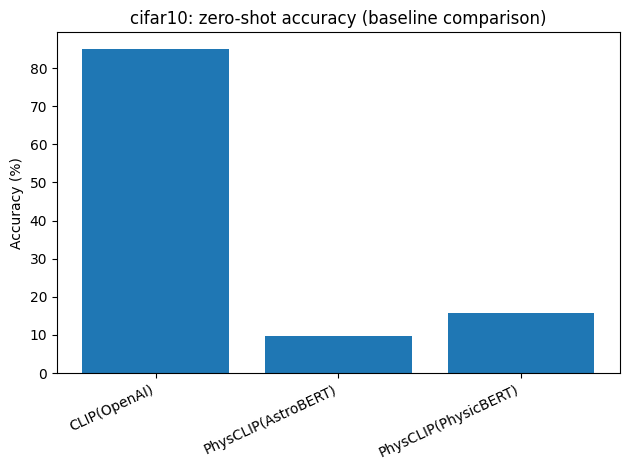

Saved: /content/drive/MyDrive/physclip_benchmark/results/figures/spacenet_zero_shot_bars.png


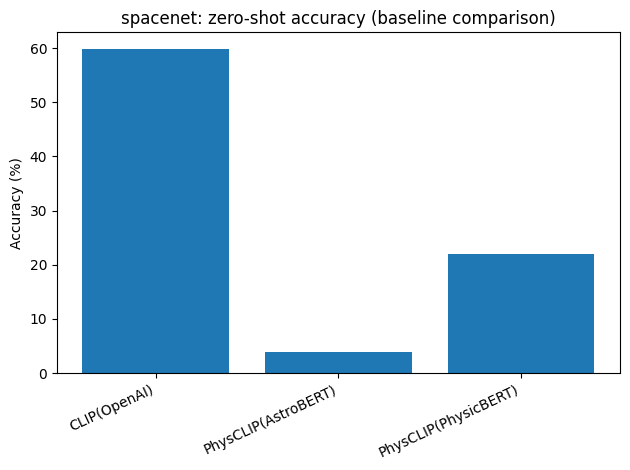

Saved: /content/drive/MyDrive/physclip_benchmark/results/figures/cifar10_shot_curve_lines.png


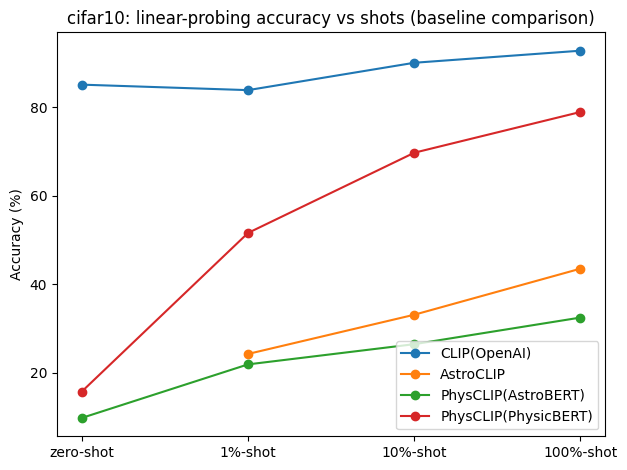

Saved: /content/drive/MyDrive/physclip_benchmark/results/figures/spacenet_shot_curve_lines.png


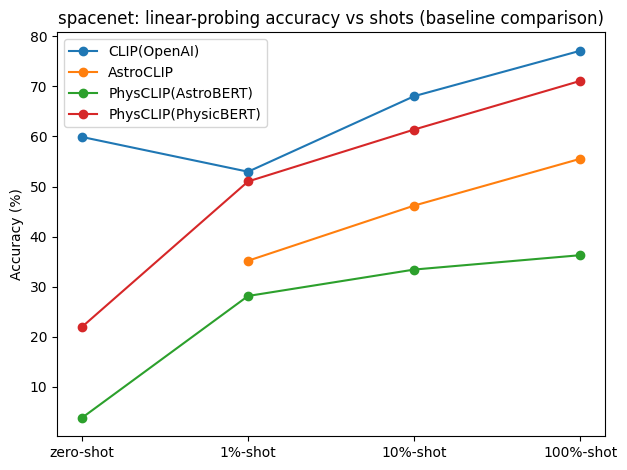

Done. Figures saved under: /content/drive/MyDrive/physclip_benchmark/results/figures


In [ ]:
# (8) Visualize image-classification results (paper-style)
# 1) Two bar charts: zero-shot accuracy (%) per dataset, comparing baselines.
# 2) Two line charts: accuracy (%) vs {zero,1%,10%,100%}, one line per baseline.

import pandas as pd
import matplotlib.pyplot as plt

in_csv = RESULTS_ROOT / "image_classification_results.csv"
if not in_csv.exists() or in_csv.stat().st_size == 0:
    raise FileNotFoundError(f"Missing results CSV: {in_csv}. Run cell (7) first.")

df = pd.read_csv(in_csv)

# Backward-compat rename (old PhysCLIP -> AstroBERT config)
df["model"] = df["model"].replace({"PhysCLIP": "PhysCLIP(AstroBERT)"})

# Keep only accuracy
df = df[df["metric"] == "acc"].copy()

DATASET_ORDER = [d for d in ["cifar10", "spacenet"] if d in df["dataset"].unique().tolist()]
MODEL_ORDER = [
    "CLIP(OpenAI)",
    "AstroCLIP",
    "PhysCLIP(AstroBERT)",
    "PhysCLIP(PhysicBERT)",
]
MODEL_ORDER = [m for m in MODEL_ORDER if m in df["model"].unique().tolist()]

FIG_ROOT = RESULTS_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

def _save(fig, name: str):
    out = FIG_ROOT / name
    fig.tight_layout()
    fig.savefig(out, dpi=200)
    print("Saved:", out)

# --- Zero-shot bar charts ---
for dataset in DATASET_ORDER:
    d0 = df[(df["dataset"] == dataset) & (df["setting"] == "zero-shot")].copy()
    if len(d0) == 0:
        print(f"[skip] no zero-shot rows for dataset={dataset}")
        continue

    # pick last value per model
    d0 = d0.sort_values("value").drop_duplicates(subset=["model"], keep="last")
    d0["acc_pct"] = 100.0 * d0["value"]

    # reindex in fixed order
    d0 = d0.set_index("model").reindex(MODEL_ORDER).reset_index()
    d0 = d0.dropna(subset=["acc_pct"])

    fig = plt.figure()
    plt.bar(d0["model"], d0["acc_pct"])
    plt.ylabel("Accuracy (%)")
    plt.title(f"{dataset}: zero-shot accuracy (baseline comparison)")
    plt.xticks(rotation=25, ha="right")
    _save(fig, f"{dataset}_zero_shot_bars.png")
    plt.show()

# --- Linear probe curves (one line per baseline) ---
SHOT_ORDER = [
    ("zero-shot", "zero-shot"),
    ("linear-probe-1%", "1%-shot"),
    ("linear-probe-10%", "10%-shot"),
    ("linear-probe-100%", "100%-shot"),
]

for dataset in DATASET_ORDER:
    fig = plt.figure()
    any_line = False

    for model in MODEL_ORDER:
        sub = df[(df["dataset"] == dataset) & (df["model"] == model)]
        if len(sub) == 0:
            continue

        xs, ys = [], []
        for setting, xlab in SHOT_ORDER:
            row = sub[sub["setting"] == setting]
            if len(row) == 0:
                continue
            xs.append(xlab)
            ys.append(100.0 * float(row.iloc[-1]["value"]))

        if len(xs) >= 2:
            plt.plot(xs, ys, marker="o", label=model)
            any_line = True

    if not any_line:
        print(f"[skip] no shot-curve rows for dataset={dataset}")
        plt.close(fig)
        continue

    plt.ylabel("Accuracy (%)")
    plt.title(f"{dataset}: linear-probing accuracy vs shots (baseline comparison)")
    plt.legend()
    _save(fig, f"{dataset}_shot_curve_lines.png")
    plt.show()

print("Done. Figures saved under:", FIG_ROOT)


## Cross-modal retrieval (PhysCLIP-Arxiv) — code skeleton

You will upload your own dataset later.  
This section implements **everything except dataset loading**.

Expected dataset format (you will fill in):
- `pairs`: a list of dicts, each dict contains:
  - `image_path`: absolute or dataset-root-relative path to the figure image
  - `caption`: the corresponding figure caption text
- Optional: you can split into `train/dev/test`, but retrieval is usually evaluated on a single held-out set.


In [ ]:
# (9) Cross-modal retrieval evaluation (Recall@1/5/10)
# TODO: fill dataset loading later.

from typing import Iterable

def recall_at_k(ranks: np.ndarray, k: int) -> float:
    return float(np.mean(ranks < k))

@torch.no_grad()
def encode_images_from_pairs(pairs: List[Dict], dataset_root: Path, baseline: Baseline, batch_size: int = 128) -> np.ndarray:
    # image preprocessing expects PIL -> tensor
    imgs = []
    for p in pairs:
        img = Image.open(Path(dataset_root) / p["image_path"]).convert("RGB")
        imgs.append(baseline.preprocess(img))
    X = torch.stack(imgs, dim=0)

    embs = []
    for i in range(0, len(X), batch_size):
        z = baseline.encode_image_batch(X[i:i+batch_size])
        embs.append(z.numpy())
    return np.concatenate(embs, axis=0)

@torch.no_grad()
def encode_texts_from_pairs(pairs: List[Dict], baseline: Baseline, batch_size: int = 128) -> np.ndarray:
    assert baseline.has_text and baseline.encode_text_batch is not None
    texts = [p["caption"] for p in pairs]
    embs = []
    for i in range(0, len(texts), batch_size):
        z = baseline.encode_text_batch(texts[i:i+batch_size])
        embs.append(z.numpy())
    return np.concatenate(embs, axis=0)

def eval_retrieval(pairs: List[Dict], dataset_root: Path, baseline: Baseline) -> Dict[str, float]:
    """Image->Text and Text->Image retrieval on aligned pairs."""
    if not baseline.has_text:
        return {"R@1_i2t": None, "R@5_i2t": None, "R@10_i2t": None,
                "R@1_t2i": None, "R@5_t2i": None, "R@10_t2i": None}

    Zi = encode_images_from_pairs(pairs, dataset_root, baseline)   # (N,D)
    Zt = encode_texts_from_pairs(pairs, baseline)                  # (N,D)

    S = Zi @ Zt.T  # cosine sim (normalized)

    # image->text ranks (correct text is same index)
    ranks_i2t = np.argsort(-S, axis=1)
    gt = np.arange(len(pairs))
    pos_i2t = np.array([np.where(ranks_i2t[i] == gt[i])[0][0] for i in range(len(pairs))])

    # text->image ranks
    ranks_t2i = np.argsort(-S.T, axis=1)
    pos_t2i = np.array([np.where(ranks_t2i[i] == gt[i])[0][0] for i in range(len(pairs))])

    out = {
        "R@1_i2t": recall_at_k(pos_i2t, 1),
        "R@5_i2t": recall_at_k(pos_i2t, 5),
        "R@10_i2t": recall_at_k(pos_i2t, 10),
        "R@1_t2i": recall_at_k(pos_t2i, 1),
        "R@5_t2i": recall_at_k(pos_t2i, 5),
        "R@10_t2i": recall_at_k(pos_t2i, 10),
    }
    return out

# ---------------------------
# TODO: LOAD YOUR DATASET HERE
# ---------------------------
# Example placeholder:
# PHYS_ARXIV_ROOT = DATA_ROOT / "physclip_arxiv"   # folder you will upload later
# pairs_test = [...]  # list of dicts: {"image_path": "...", "caption": "..."}
# assert len(pairs_test) > 0

# When ready:
# for base in [clip, physclip]:   # AstroCLIP skipped (no text)
#     if base is None:
#         continue
#     scores = eval_retrieval(pairs_test, PHYS_ARXIV_ROOT, base)
#     print(base.name, scores)



NameError: name 'np' is not defined